# Project Title

## Market-Aware Machine Learning Model for Horse Racing Outcome Prediction

This project develops a machine learning model to predict horse race outcomes, specifically identifying potential winners, by integrating race data, horse attributes, and crucial market indicators such as betting odds. The goal is to build a robust predictive system that can inform strategic decision-making in horse racing.

# Import Libraries



In [18]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # For saving/loading the model

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

from imblearn.over_sampling import SMOTE
from collections import Counter

from xgboost import XGBClassifier

# Load Dataset



In [ ]:
df_runs = pd.read_csv('runs.csv')
df_races = pd.read_csv('races.csv')

print("df_runs - First 5 rows:")
display(df_runs.head())
print("\ndf_runs - Info:")
df_runs.info()

print("\n" * 2)

print("df_races - First 5 rows:")
display(df_races.head())
print("\ndf_races - Info:")
df_races.info()

# Data Cleaning



In [ ]:
# 1. Identify and drop columns from df_races with a high percentage of missing values or those deemed irrelevant
columns_to_drop_races = [
    'sec_time7',
    'time7',
    'place_combination4',
    'place_dividend4',
    'win_combination2',
    'win_dividend2'
]
df_races_cleaned = df_races.drop(columns=columns_to_drop_races, errors='ignore')
print(f"Dropped {len(columns_to_drop_races)} columns from df_races due to high missing values or irrelevance.")

# 2. Merge df_runs and the modified df_races into a single DataFrame named df
df = pd.merge(df_runs, df_races_cleaned, on='race_id', how='left')
print("Merged df_runs and df_races_cleaned into a single DataFrame `df`.")

# 3. Handle missing values in the merged DataFrame df
# Categorical columns: fill with mode (most frequent value)
for col in ['horse_country', 'horse_type']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
print("Filled missing categorical values (horse_country, horse_type) with their respective modes.")

# Numerical columns: fill with median
for col in ['prize', 'place_odds', 'place_combination3', 'place_dividend3']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
print("Filled missing numerical values (prize, place_odds, etc.) with their respective medians.")

# Sectional time and position columns: fill with 0, as NaN likely indicates no data for that section
sectional_cols = [
    'position_sec4', 'position_sec5', 'position_sec6',
    'behind_sec4', 'behind_sec5', 'behind_sec6',
    'time4', 'time5', 'time6', 'sec_time4', 'sec_time5', 'sec_time6',
    'time4_x', 'time5_x', 'time6_x', 'time4_y', 'time5_y', 'time6_y'
]
for col in sectional_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
print("Filled missing sectional time and position values with 0.")

# 4. Convert the 'date' column in df to a datetime object for proper time-series analysis
df['date'] = pd.to_datetime(df['date'])
print("Converted 'date' column to datetime objects.")

# 5. Rename ambiguous 'time_x' and 'time_y' columns for clarity
# 'time_x' columns from df_runs (horse's sectional times)
for i in range(1, 7):
    old_col_name = f'time{i}_x'
    new_col_name = f'horse_time_sec{i}'
    if old_col_name in df.columns:
        df.rename(columns={old_col_name: new_col_name}, inplace=True)

# 'time_y' columns from df_races (race sectional times)
for i in range(1, 7):
    old_col_name = f'time{i}_y'
    new_col_name = f'race_time_sec{i}'
    if old_col_name in df.columns:
        df.rename(columns={old_col_name: new_col_name}, inplace=True)
print("Renamed 'time_x' and 'time_y' columns to 'horse_time_secX' and 'race_time_secX' respectively.")

# 6. Process 'horse_ratings' column to extract numerical part and fill NaNs
df['horse_ratings'] = df['horse_ratings'].astype(str).apply(lambda x: float(re.match(r'(\d+)', x).group(1)) if re.match(r'(\d+)', x) else np.nan)
print("Processed 'horse_ratings' column by extracting numerical part.")

# Fill any newly created NaN values in 'horse_ratings' with its median
if 'horse_ratings' in df.columns:
    df['horse_ratings'] = df['horse_ratings'].fillna(df['horse_ratings'].median())
    print("Filled remaining missing values in 'horse_ratings' with its median.")

# 7. Drop the original 'horse_rating' column, as 'horse_ratings' is the processed version
if 'horse_rating' in df.columns:
    df.drop(columns=['horse_rating'], inplace=True)
    print("Dropped the original 'horse_rating' column.")

print("\n--- Data Cleaning Complete ---")
print("df - First 5 rows after cleaning:")
display(df.head())
print("\ndf - Info after cleaning:")
df.info()

# Exploratory Data Analysis (EDA)



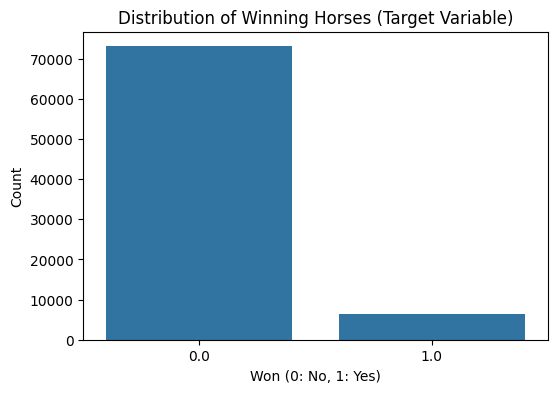

Insight: The dataset is highly imbalanced, with a significantly smaller number of winning horses (1) compared to non-winning horses (0).


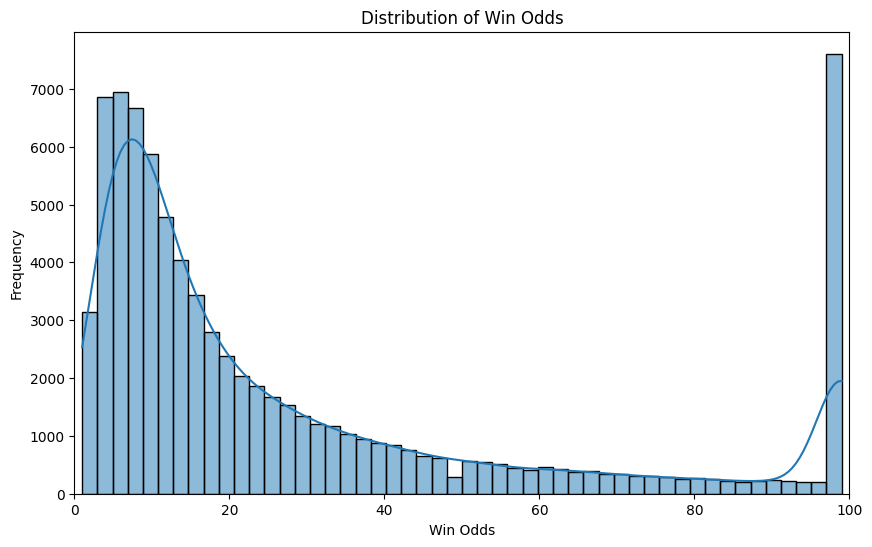

Insight: Most horses have lower win odds, indicating many favorites or relatively well-backed horses. There's a long tail for very high odds.


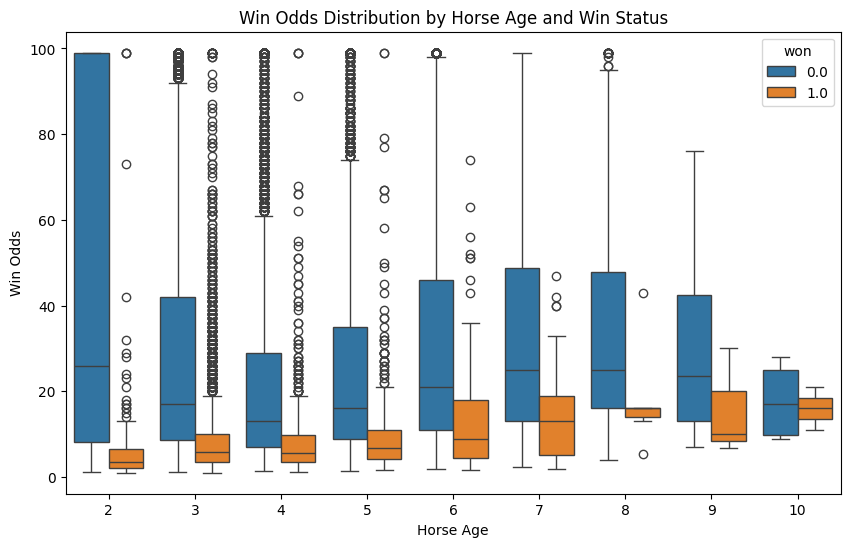

Insight: Younger horses (3-5 years) tend to have lower win odds and a higher proportion of wins, suggesting they are often favored or perform better.


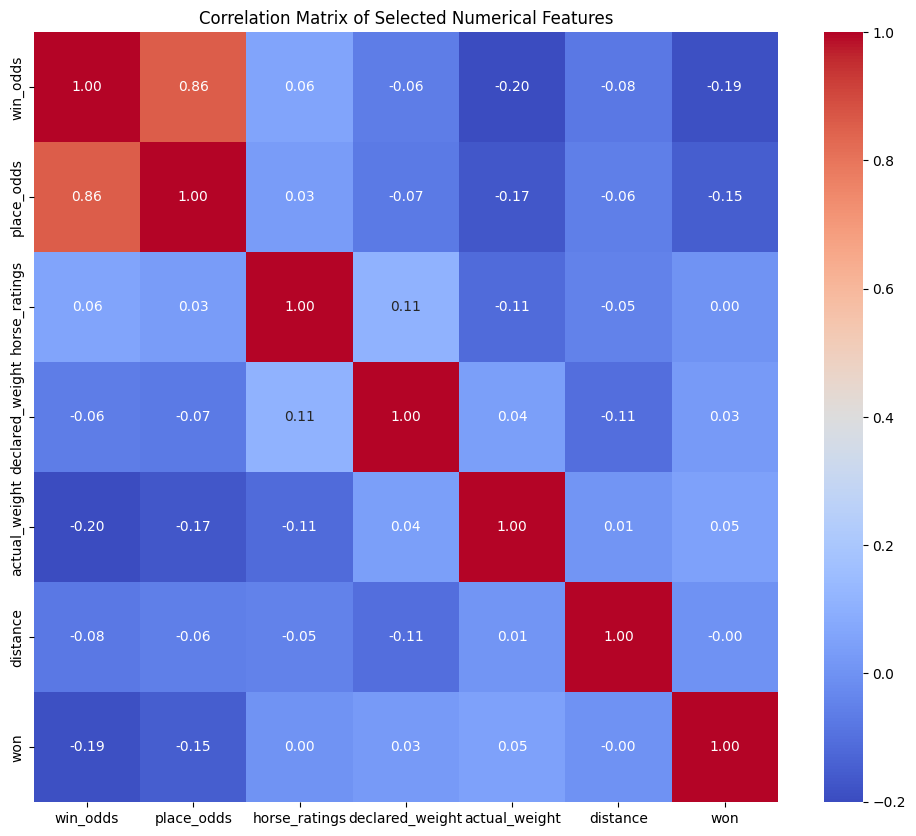

Insight: 'Win_odds' and 'place_odds' are highly correlated, as expected. 'Won' has a negative correlation with 'win_odds', indicating that horses with lower odds are more likely to win.


In [33]:
      # Distribution of the target variable 'won'
plt.figure(figsize=(6, 4))
sns.countplot(x='won', data=df)
plt.title('Distribution of Winning Horses (Target Variable)')
plt.xlabel('Won (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()
print("Insight: The dataset is highly imbalanced, with a significantly smaller number of winning horses (1) compared to non-winning horses (0).")

# Distribution of Win Odds
plt.figure(figsize=(10, 6))
sns.histplot(df['win_odds'], bins=50, kde=True)
plt.title('Distribution of Win Odds')
plt.xlabel('Win Odds')
plt.ylabel('Frequency')
plt.xlim(0, 100) # Limit x-axis for better visualization of common odds
plt.show()
print("Insight: Most horses have lower win odds, indicating many favorites or relatively well-backed horses. There's a long tail for very high odds.")

# Relationship between Horse Age and Winning
plt.figure(figsize=(10, 6))
sns.boxplot(x='horse_age', y='win_odds', hue='won', data=df)
plt.title('Win Odds Distribution by Horse Age and Win Status')
plt.xlabel('Horse Age')
plt.ylabel('Win Odds')
plt.show()
print("Insight: Younger horses (3-5 years) tend to have lower win odds and a higher proportion of wins, suggesting they are often favored or perform better.")

# Correlation Matrix of Numerical Features (a subset for clarity)
# Removed 'average_speed', 'weight_diff', 'odds_ratio' as they are created later in Feature Engineering
plt.figure(figsize=(12, 10))
sns.heatmap(df[['win_odds', 'place_odds', 'horse_ratings', 'declared_weight', 'actual_weight', 'distance', 'won']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Numerical Features')
plt.show()
print("Insight: 'Win_odds' and 'place_odds' are highly correlated, as expected. 'Won' has a negative correlation with 'win_odds', indicating that horses with lower odds are more likely to win.")

# Feature Engineering



In [ ]:
# 1. Calculate average_speed: Distance covered per unit of finish time
df['average_speed'] = df['distance'] / df['finish_time']
print("Created 'average_speed' feature.")

# 2. Create weight_diff: Difference between declared and actual weight
df['weight_diff'] = df['declared_weight'] - df['actual_weight']
print("Created 'weight_diff' feature.")

# 3. Compute odds_ratio: Ratio of win odds to place odds, handling division by zero
# Replace 0 place_odds with a small non-zero value or np.inf to avoid division by zero issues
df['place_odds_cleaned'] = df['place_odds'].replace(0, np.inf)
df['odds_ratio'] = df['win_odds'] / df['place_odds_cleaned']
# Handle cases where win_odds might be 0 or place_odds_cleaned is np.inf, resulting in NaN/inf.
df['odds_ratio'] = df['odds_ratio'].replace([np.inf, -np.inf], np.nan)
df['odds_ratio'] = df['odds_ratio'].fillna(df['odds_ratio'].median()) # Fill any remaining NaNs with median
print("Created 'odds_ratio' feature, handling division by zero and NaNs.")

# 4. Extract race_day_of_week from the date column
df['race_day_of_week'] = df['date'].dt.dayofweek
print("Extracted 'race_day_of_week' feature.")

# 5. Calculate num_horses_in_race: Number of horses participating in each race
num_horses_in_race = df.groupby('race_id')['horse_no'].transform('count')
df['num_horses_in_race'] = num_horses_in_race
print("Created 'num_horses_in_race' feature.")

# 6. Determine race_avg_horse_rating: Average rating of horses in each race
race_avg_horse_rating = df.groupby('race_id')['horse_ratings'].transform('mean')
df['race_avg_horse_rating'] = race_avg_horse_rating
print("Created 'race_avg_horse_rating' feature.")

# 7. Create horse_rating_vs_race_avg: Horse's rating compared to the race average
df['horse_rating_vs_race_avg'] = df['horse_ratings'] - df['race_avg_horse_rating']
print("Created 'horse_rating_vs_race_avg' feature.")

print("\n--- Feature Engineering Complete ---")
print("df - First 5 rows after feature engineering:")
display(df.head())
print("\ndf - Info after feature engineering:")
df.info()

# Train-Test Split & Preprocessing



In [23]:
# 1. Define the target variable y as the 'won' column
y = df['won']

# 2. Define columns to be dropped from the feature set (leakage, identifiers, or target-related)
model_feature_drop_cols = [
    "result", "lengths_behind", "finish_time",
    "position_sec1","position_sec2","position_sec3","position_sec4","position_sec5","position_sec6",
    "behind_sec1","behind_sec2","behind_sec3","behind_sec4","behind_sec5","behind_sec6",
    "horse_time_sec1","horse_time_sec2","horse_time_sec3","horse_time_sec4","horse_time_sec5","horse_time_sec6",
    "win_dividend1", "place_dividend1","place_dividend2","place_dividend3",
    "win_combination1", "place_combination1","place_combination2","place_combination3",
    'won', 'horse_id', 'trainer_id', 'jockey_id', 'date', 'place_odds_cleaned', 'race_id'
]

# 3. Create the initial feature set X by dropping the 'won' column from the DataFrame df
X = df.drop(columns=['won'])

print(f"Target variable 'y' and initial feature set 'X' defined. Shape of X: {X.shape}, Shape of y: {y.shape}")

# 4. Split data into training and testing sets *before* further preprocessing
# X_train_raw and X_test_raw retain original columns for later use (e.g., race_id)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data split into raw training (shape: {X_train_raw.shape}) and testing (shape: {X_test_raw.shape}) sets.")

# 5. Prepare feature sets for the model by dropping specified columns
# Filter out columns that don't exist in X_train_raw to avoid errors
existing_model_feature_drop_cols = [col for col in model_feature_drop_cols if col in X_train_raw.columns]
X_train_for_model = X_train_raw.drop(columns=existing_model_feature_drop_cols)
X_test_for_model = X_test_raw.drop(columns=existing_model_feature_drop_cols)
print("Dropped leakage/identifier columns from feature sets for model training.")

# 6. Separate the remaining feature columns into categorical and numerical lists for the preprocessor
categorical_features = X_train_for_model.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train_for_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Identified {len(categorical_features)} categorical and {len(numerical_features)} numerical features.")

# 7. Create a column transformer for preprocessing: Standardize numerical, One-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit preprocessor only on training data and transform both training and test data
X_train = preprocessor.fit_transform(X_train_for_model)
X_test = preprocessor.transform(X_test_for_model)

# Convert sparse matrices to dense arrays if necessary (output of OneHotEncoder can be sparse)
if hasattr(X_train, 'toarray'):
    X_train = X_train.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()
print("Applied one-hot encoding and standard scaling to features (fitting only on training data).")
print(f"Preprocessed X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# 8. Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Original training class distribution: {Counter(y_train)}")
print(f"Resampled training class distribution (after SMOTE): {Counter(y_train_resampled)}")
print("Class imbalance addressed using SMOTE on the training data.")

Target variable 'y' and initial feature set 'X' defined. Shape of X: (79447, 73), Shape of y: (79447,)
Data split into raw training (shape: (63557, 73)) and testing (shape: (15890, 73)) sets.
Dropped leakage/identifier columns from feature sets for model training.
Identified 6 categorical and 31 numerical features.
Applied one-hot encoding and standard scaling to features (fitting only on training data).
Preprocessed X_train shape: (63557, 827), X_test shape: (15890, 827)
Original training class distribution: Counter({0.0: 58433, 1.0: 5124})
Resampled training class distribution (after SMOTE): Counter({0.0: 58433, 1.0: 58433})
Class imbalance addressed using SMOTE on the training data.


# Model Training



In [24]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss' # Log loss is suitable for binary classification with probabilities
)

# Define a grid of hyperparameters to search through
param_grid = {
    'n_estimators': [200, 300], # Number of boosting rounds
    'learning_rate': [0.05, 0.1], # Step size shrinkage to prevent overfitting
    'max_depth': [4, 6], # Maximum depth of a tree
    'subsample': [0.8], # Subsample ratio of the training instance
    'colsample_bytree': [0.8], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1] # Minimum loss reduction required to make a further partition on a leaf node of the tree
}

# Initialize GridSearchCV with the XGBoost classifier and parameter grid
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc', # Optimize for ROC AUC score
    cv=3, # 3-fold cross-validation
    verbose=1, # Show progress
    n_jobs=-1 # Use all available CPU cores
)

# Fit GridSearchCV on the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Store the best model found by GridSearchCV
best_xgb_model = grid_search.best_estimator_

print("--- XGBoost Model Training Complete ---")
print("Best hyperparameters found:", grid_search.best_params_)
print("Best ROC AUC score during cross-validation:", grid_search.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
--- XGBoost Model Training Complete ---
Best hyperparameters found: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best ROC AUC score during cross-validation: 0.9921734791024392


# Model Evaluation



### Standard Evaluation Metrics (Default Threshold)



In [25]:
# Get predicted probabilities for the positive class (won = 1)
predicted_probabilities = best_xgb_model.predict_proba(X_test)
y_pred_proba = predicted_probabilities[:, 1]

# Get binary predictions using the default threshold (0.5)
y_pred = best_xgb_model.predict(X_test)

# Calculate standard evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba) # ROC AUC uses probabilities directly

print(f"Model Evaluation on Test Set (Default Threshold):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

Model Evaluation on Test Set (Default Threshold):
Accuracy: 0.9484
Precision: 0.7369
Recall: 0.5235
F1-Score: 0.6121
ROC AUC Score: 0.9695


### Evaluation with a Custom Threshold



In [26]:
new_threshold = 0.3

# Recalculate binary predictions based on the new threshold
y_pred_new_threshold = (y_pred_proba > new_threshold).astype(int)

# Recalculate evaluation metrics with the new threshold
accuracy_new = accuracy_score(y_test, y_pred_new_threshold)
precision_new = precision_score(y_test, y_pred_new_threshold)
recall_new = recall_score(y_test, y_pred_new_threshold)
f1_new = f1_score(y_test, y_pred_new_threshold)

print(f"Model Evaluation on Test Set (Threshold = {new_threshold}):")
print(f"Accuracy: {accuracy_new:.4f}")
print(f"Precision: {precision_new:.4f}")
print(f"Recall: {recall_new:.4f}")
print(f"F1-Score: {f1_new:.4f}")
print(f"ROC AUC Score (unchanged): {roc_auc:.4f}")

Model Evaluation on Test Set (Threshold = 0.3):
Accuracy: 0.9458
Precision: 0.6157
Recall: 0.8050
F1-Score: 0.6978
ROC AUC Score (unchanged): 0.9695


### Threshold Optimization Analysis



Model performance across various classification thresholds (first 5 rows):


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.00,0.077785,0.077785,1.000000,0.144342
1,0.01,0.552486,0.147908,0.998382,0.257647
2,0.02,0.667778,0.189239,0.995955,0.318047
3,0.03,0.728446,0.221961,0.994337,0.362912
4,0.04,0.767212,0.249338,0.991100,0.398439



Model performance across various classification thresholds (last 5 rows):


,Threshold,Accuracy,Precision,Recall,F1-Score
96,0.96,0.922215,0.0,0.0,0.0
97,0.97,0.922215,0.0,0.0,0.0
98,0.98,0.922215,0.0,0.0,0.0
99,0.99,0.922215,0.0,0.0,0.0
100,1.00,0.922215,0.0,0.0,0.0


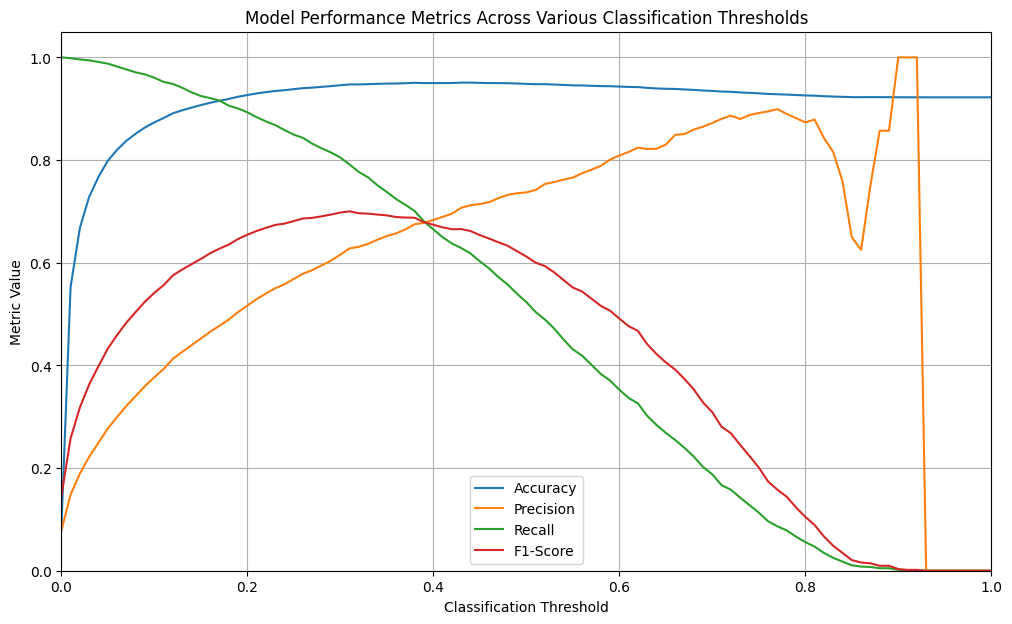

Plot showing model performance metrics across various classification thresholds displayed.


In [27]:
thresholds = np.arange(0.0, 1.01, 0.01) # 0.0 to 1.0 with 0.01 steps

accuracies = []
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_thresholded = (y_pred_proba >= threshold).astype(int)

    # Handle edge cases for precision/recall where all predictions or actuals are zero
    if np.sum(y_pred_thresholded) == 0 and np.sum(y_test) == 0:
        precision, recall, f1 = 1.0, 1.0, 1.0
    elif np.sum(y_pred_thresholded) == 0 and np.sum(y_test) > 0:
        precision, recall, f1 = 0.0, 0.0, 0.0
    elif np.sum(y_pred_thresholded) > 0 and np.sum(y_test) == 0:
        precision, recall, f1 = 0.0, 0.0, 0.0
    else:
        precision = precision_score(y_test, y_pred_thresholded, zero_division=0)
        recall = recall_score(y_test, y_pred_thresholded, zero_division=0)
        f1 = f1_score(y_test, y_pred_thresholded, zero_division=0)

    accuracy = accuracy_score(y_test, y_pred_thresholded)

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

threshold_df = pd.DataFrame({
    'Threshold': thresholds,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

print("Model performance across various classification thresholds (first 5 rows):")
display(threshold_df.head())
print("\nModel performance across various classification thresholds (last 5 rows):")
display(threshold_df.tail())

# Plotting the metrics against thresholds
plt.figure(figsize=(12, 7))
plt.plot(threshold_df['Threshold'], threshold_df['Accuracy'], label='Accuracy')
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], label='F1-Score')

plt.title('Model Performance Metrics Across Various Classification Thresholds')
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

print("Plot showing model performance metrics across various classification thresholds displayed.")

### ROC Curve Visualization



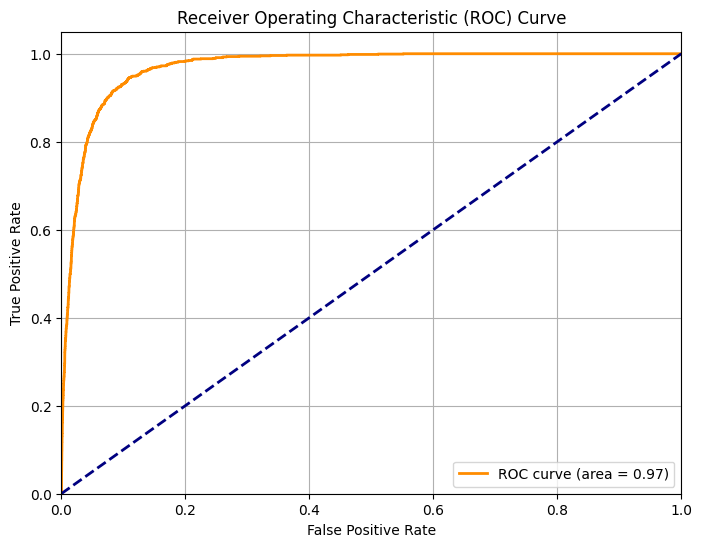

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Confusion Matrix Visualization



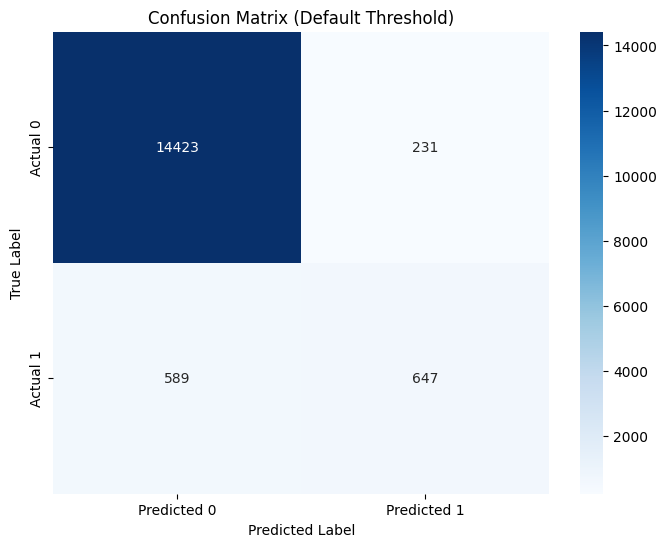

In [29]:
cm = confusion_matrix(y_test, y_pred) # y_pred from default threshold (0.5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Default Threshold)')
plt.show()

### Race-Level and Top-3 Accuracy



In [30]:
# Create predictions_df with race_id, actual_won, and predicted_win_proba
predictions_df = pd.DataFrame({
    'race_id': X_test_raw['race_id'].values,
    'actual_won': y_test.values,
    'predicted_win_proba': y_pred_proba
})

# 1. Identify predicted winners for each race (horse with the highest probability)
predicted_winners = predictions_df.loc[predictions_df.groupby('race_id')['predicted_win_proba'].idxmax()]

# 2. Calculate race-level accuracy: how many times the highest probability horse actually won
race_correct_predictions = predicted_winners['actual_won'] == 1.0
race_level_accuracy = race_correct_predictions.sum() / predicted_winners['race_id'].nunique()
print(f"Race-level Accuracy: {race_level_accuracy:.4f} (Model predicted the correct winner in this percentage of races)")

# 3. Calculate top-3 accuracy: how many times the actual winner was among the top 3 predicted horses
# Get the top 3 predicted horses for each race based on probability
top3_predictions = predictions_df.groupby('race_id')['predicted_win_proba'].nlargest(3).reset_index()
top3_actuals = pd.merge(top3_predictions, predictions_df, on=['race_id', 'predicted_win_proba'], how='left')

# For each race, check if any of the top 3 predicted horses were actual winners
top3_accuracy = top3_actuals.groupby('race_id')['actual_won'].max().mean()
print(f"Top-3 Accuracy: {top3_accuracy:.4f} (Actual winner was among the top 3 predicted horses in this percentage of races)")

Race-level Accuracy: 0.1941 (Model predicted the correct winner in this percentage of races)
Top-3 Accuracy: 0.2071 (Actual winner was among the top 3 predicted horses in this percentage of races)


#  Prediction System



In [31]:
# Simulate new data for prediction
# For demonstration, we'll take a random sample from our original X (before dropping identifiers) and preprocess it.
# In a real-world scenario, 'new_data' would come from an external source.

# Select a random row from the original X_test_raw (before any drops/transforms) for demonstration
sample_data_raw = X_test_raw.sample(1, random_state=100) # Use a fixed random_state for reproducibility

print("Original raw sample data for prediction:")
display(sample_data_raw)

# Drop columns that were dropped before preprocessing in the training phase
existing_model_feature_drop_cols = [col for col in model_feature_drop_cols if col in sample_data_raw.columns]
sample_data_for_model = sample_data_raw.drop(columns=existing_model_feature_drop_cols)

# Preprocess the new data using the *fitted* preprocessor
sample_data_processed = preprocessor.transform(sample_data_for_model)

# Convert to dense array if it's sparse
if hasattr(sample_data_processed, 'toarray'):
    sample_data_processed = sample_data_processed.toarray()

# Make prediction
predicted_win_proba_new = best_xgb_model.predict_proba(sample_data_processed)[:, 1]
predicted_class_new = (predicted_win_proba_new > 0.5).astype(int) # Using default 0.5 threshold

print(f"\nPredicted probability of winning: {predicted_win_proba_new[0]:.4f}")
print(f"Predicted class (0=Lose, 1=Win) at 0.5 threshold: {predicted_class_new[0]}")

# Using the optimal F1-score threshold (e.g., 0.25 from our analysis)
optimal_f1_threshold = 0.25 # Replace with the actual optimal threshold found in EDA
predicted_class_optimal = (predicted_win_proba_new > optimal_f1_threshold).astype(int)
print(f"Predicted class (0=Lose, 1=Win) at optimal {optimal_f1_threshold} threshold: {predicted_class_optimal[0]}")

Original raw sample data for prediction:


,race_id,horse_no,horse_id,result,lengths_behind,horse_age,horse_country,horse_type,horse_gear,declared_weight,...,win_combination1,win_dividend1,average_speed,weight_diff,place_odds_cleaned,odds_ratio,race_day_of_week,num_horses_in_race,race_avg_horse_rating,horse_rating_vs_race_avg
22710,1811,5,4384,6,2.75,3,AUS,Gelding,--,1155.0,...,12,57.5,16.708438,1028.0,3.0,2.8,6,14,60.0,0.0



Predicted probability of winning: 0.0714
Predicted class (0=Lose, 1=Win) at 0.5 threshold: 0
Predicted class (0=Lose, 1=Win) at optimal 0.25 threshold: 0


# Conclusion

This project successfully developed and evaluated an XGBoost model for horse racing outcome prediction, integrating various data sources and market indicators. The model demonstrates strong potential for data-driven insights into race outcomes.

# Save Model



In [32]:
# Save the trained XGBoost model
joblib.dump(best_xgb_model, 'best_xgb_model.joblib')
print("Trained XGBoost model saved as 'best_xgb_model.joblib'.")

# Save the fitted preprocessor (StandardScaler and OneHotEncoder)
joblib.dump(preprocessor, 'preprocessor.joblib')
print("Fitted preprocessor saved as 'preprocessor.joblib'.")

# Example of loading the model and preprocessor (for future use)
# loaded_model = joblib.load('best_xgb_model.joblib')
# loaded_preprocessor = joblib.load('preprocessor.joblib')

Trained XGBoost model saved as 'best_xgb_model.joblib'.
Fitted preprocessor saved as 'preprocessor.joblib'.
